In [1]:
import pandas as pd, si_units as si, ternary, matplotlib.pyplot as plt, numpy as np, PLOT_SETTINGS as ps, matplotlib.ticker as ticker, ast, os, feos
from molmass import Formula
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D
from io import StringIO

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

co2 = Formula("CO2")
ch4 = Formula("CH4")
n2  = Formula("N2")
h2  = Formula("H2")
ar  = Formula("Ar")

def M_mix(x_co2):
    return x_co2 * co2.mass + (1.0 - x_co2) * ch4.mass  # kg/mol

def mass_density(molar_density, M):  # mol/m^3 * kg/mol -> kg/m^3
    return (molar_density * M) / (si.KILO * si.MOL / si.METER**3)

In [2]:
def value_in(q, unit):
    """Return the numeric value of q in the given unit."""
    if isinstance(q, (int, float, np.floating)):
        return float(q)
    return np.asarray(q / unit, dtype=float)


def molar_density_mol_m3(rho):
    """Convert molar density to mol/m^3."""
    mol_per_m3 = si.MOL / (si.METER**3)
    try:
        return value_in(rho, mol_per_m3)
    except Exception:
        pass
    try:
        kmol_per_m3 = si.KMOL / (si.METER**3)
        return value_in(rho, kmol_per_m3) * 1000.0
    except Exception:
        pass
    try:
        kmol_per_m3 = (1000.0 * si.MOL) / (si.METER**3)
        return value_in(rho, kmol_per_m3) * 1000.0
    except Exception as e:
        raise TypeError(f"Could not interpret density units") from e

def density_kg_m3(rho_molar, z, molar_masses, molar_mass_unit="g/mol"):
    """Convert molar density to mass density (kg/m^3)."""
    z = np.asarray(z, dtype=float)
    M = np.asarray(molar_masses, dtype=float)
    
    if molar_mass_unit.lower() == "g/mol":
        M = M / 1000.0
    elif molar_mass_unit.lower() == "kg/mol":
        pass
    else:
        raise ValueError("molar_mass_unit must be 'g/mol' or 'kg/mol'.")
    
    rho_mol_m3 = molar_density_mol_m3(rho_molar)
    M_mix = np.sum(z * M)
    return rho_mol_m3 * M_mix

In [3]:
z               = np.array([0.25, 0.25, 0.5])  # mole fractions of Argon, Nitrogen, Hydrogen
parameters      = feos.Parameters.from_json(["argon", "nitrogen", "hydrogen"], "parameters.json",binary_path="binary.json")
pcsaft_helmz    = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
T               = 100* si.KELVIN
P               = 20e5* si.PASCAL
feed            = z * si.MOL
molar_masses    = np.array([ar.mass, n2.mass, h2.mass])  #g/mol
print(f"Molar masses of the components in the ternary mixtures: {molar_masses} g/mol")
parameters

Molar masses of the components in the ternary mixtures: [39.948    28.013406  2.015882] g/mol


|component|molarweight|m|sigma|epsilon_k|nb|
|-|-|-|-|-|-|
|argon|39.962|1.0|3.37751|117.80903||
|nitrogen|28.006|1.23831|3.30009|89.41358|2.0|
|hydrogen|2.016|1.0|3.002|51.343||

|component 1|component 2|k_ij|l_ij|
|-|-|-|-|
|argon|nitrogen|0.03|0.0|
|argon|hydrogen|0.01|0.0|
|nitrogen|hydrogen|0.02|0.0|

In [ ]:
# eos = feos.EquationOfState.pcsaft(parameters)
eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
eq  = feos.PhaseEquilibrium.tp_flash(eos, T, P, feed)
liq = eq.liquid
vap = eq.vapor
cp  = feos.State.critical_point(eos, feed/si.MOL, initial_temperature= T)

critical_temperature = cp.temperature
critical_pressure    = cp.pressure()
print(f"Critical Temperature (K): {critical_temperature/si.KELVIN:.4f}")
print(f"Critical Pressure (bar): {critical_pressure/si.BAR:.4f}")

Critical Temperature (K): 110.6154
Critical Pressure (bar): 70.9503


In [5]:

liquid_density          = density_kg_m3(eq.liquid.density, z, molar_masses) 
vapor_density           = density_kg_m3(eq.vapor.density, z, molar_masses)
interface               = feos.PlanarInterface.from_tanh(vle=eq,n_grid=500, l_grid=100*si.ANGSTROM, critical_temperature=critical_temperature)
solve                   = interface.solve()
surface_tension         = solve.surface_tension
interfacial_thickness   = solve.interfacial_thickness
enrichment              = solve.interfacial_enrichment
E_Ar, E_N2, E_H2        = enrichment()
density_profiles        = solve.density
cartesian_grid          = solve.z /si.ANGSTROM
profile_Ar              = density_kg_m3(density_profiles[0], 1, [ar.mass])
profile_N2              = density_kg_m3(density_profiles[1], 1, [n2.mass])
profile_H2              = density_kg_m3(density_profiles[2], 1, [h2.mass])
Gamma                   = solve.relative_adsorption()

print(f"Liquid Density:{liquid_density:.4f} (kg/m^3)")
print(f"Vapor Density: {vapor_density:.4f} (kg/m^3)")
print(f"Surface Tension: {surface_tension*1e3/si.NEWTON*si.METER:.6f} mN/m")
print(f"Interfacial Thickness: {interfacial_thickness()*1e-1/si.ANGSTROM:.6f} nm")
print("Enrichment of components:")
print(f"  Ar : {E_Ar:.3f}")
print(f"  N2 : {E_N2:.3f}")
print(f"  H2 : {E_H2:.3f}")
print(f"Relative Adsorption of components:{Gamma/si.MOL}")

Liquid Density:527.7364 (kg/m^3)
Vapor Density: 51.9802 (kg/m^3)
Surface Tension: 4.435424 mN/m
Interfacial Thickness: 1.201609 nm
Enrichment of components:
  Ar : 1.000
  N2 : 1.003
  H2 : 1.376
Relative Adsorption of components:[[ 0.00000000e+00 -4.80517385e-26 -2.61801551e-25]
 [ 3.16515116e-26  0.00000000e+00 -1.40796252e-25]
 [ 2.49741889e-26  2.03903612e-26  0.00000000e+00]]


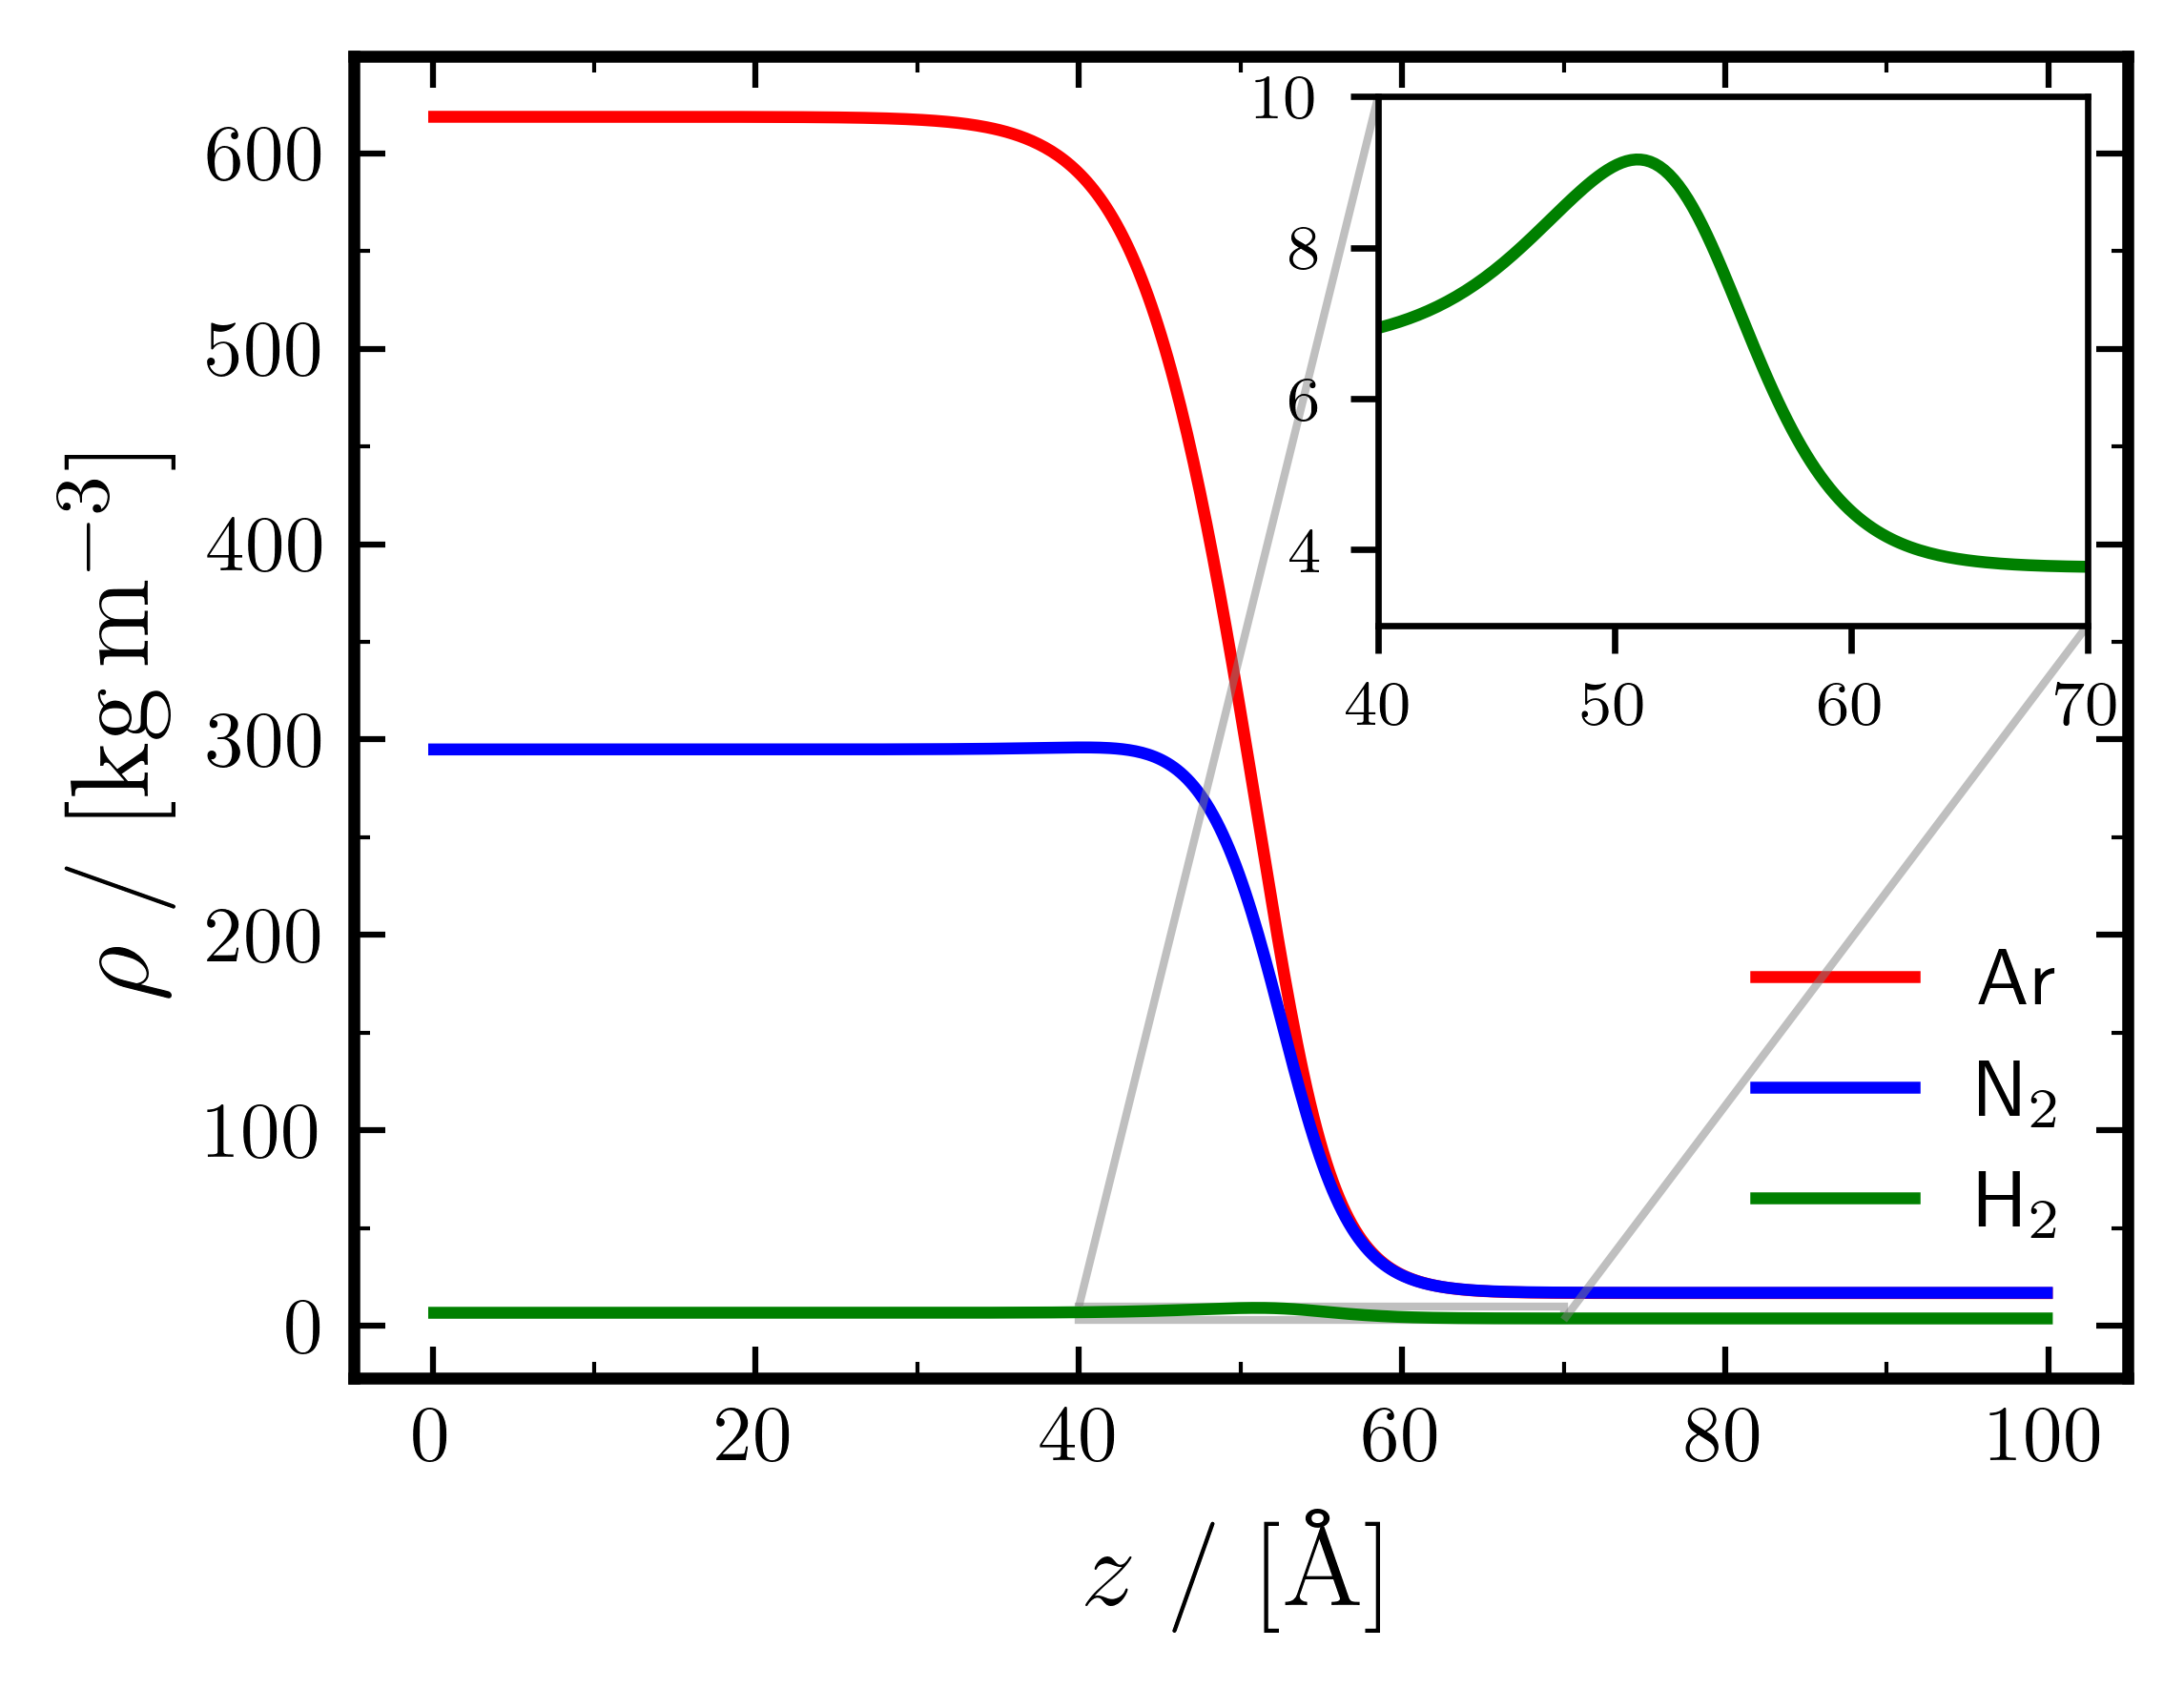

In [6]:
fig1, ax1 = ps.plot_init()

ax1.plot(cartesian_grid, profile_Ar, color='red', linestyle="-", label=r'Ar',zorder=1)
ax1.plot(cartesian_grid, profile_N2, color='blue', linestyle="-", label=r'N$_2$', zorder=2)
ax1.plot(cartesian_grid, profile_H2, color='green', linestyle="-", label=r'H$_2$', zorder=3)

ax1.set_xlabel(r'$z \; / \; [\mathrm{\AA}]$', fontsize=ps.label_fontsize)
ax1.set_ylabel(r'$\rho \; / \; [\mathrm{kg\,m^{-3}}]$', fontsize=ps.label_fontsize)

ax1.minorticks_on()
ax1.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax1.legend(loc='lower left', bbox_to_anchor=(0.75, 0.05), frameon=False)
# ax1.set_title(f"Density Profile of Ar-N$_2$-H$_2$ mixture at {temperature} K and ~{closest_pressure:.2f} bar")
ax_main = plt.gca()
ax_inset = inset_axes(ax_main, width="40%", height="40%", loc='upper right')

ax_inset.plot(cartesian_grid , profile_N2, color='blue', linestyle="-", label='N2')
ax_inset.plot(cartesian_grid , profile_Ar, color='red', linestyle="-", label='Ar')
ax_inset.plot(cartesian_grid , profile_H2, color='green', linestyle="-", label='H2')

ax_inset.set_xlim(40, 70)
ax_inset.set_ylim(3, 10)
ax_inset.tick_params(labelsize=8)

mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="gray", alpha=0.5, lw=1)

plt.show()

/home/darshan/A6/py_A6/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


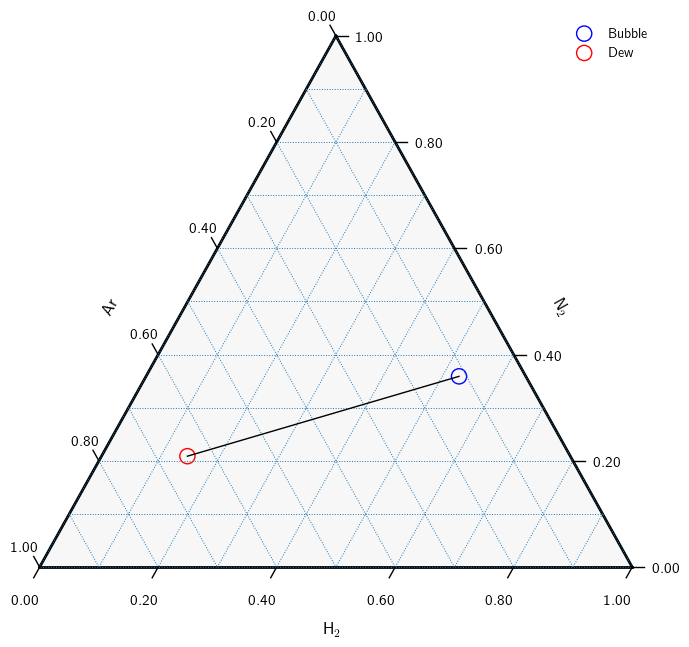

In [7]:
x_pt = [tuple(liq.molefracs.tolist())]
y_pt = [tuple(vap.molefracs.tolist())]

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(7, 6.5)

tax.boundary(linewidth=2)
tax.gridlines(multiple=0.1, linewidth=0.7)

tax.left_axis_label("Ar", offset=0.14, fontsize=12)
tax.right_axis_label("N$_2$", offset=0.14, fontsize=12)
tax.bottom_axis_label("H$_2$", offset=0.02, fontsize=12)

tax.ticks(axis="lbr",multiple=0.2,linewidth=1,fontsize=11,offset=0.02,tick_formats="%.2f")

tax.scatter(x_pt, marker="o", s=120, facecolors="none", edgecolors="blue", label="Bubble")
tax.scatter(y_pt, marker="o", s=120, facecolors="none", edgecolors="red", label="Dew")

# optional tie-line
tax.line(x_pt[0], y_pt[0], linewidth=1, color='k')

tax.get_axes().set_axis_off()
tax.clear_matplotlib_ticks()
tax.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()